In [162]:
#========================================================================
#
# Name: machine-learning-german-credit-data.ipynb
#
# Date: 06/04/2026
#
# Author: MT
# 
# Description: German Credit Data
# https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk
#
# Steps:
# Step 0: Imports
# Step 1: Load Data
# Step 2: Plot Response
# Step 3: Plot Numeric Features
# Step 4: Plot Categorical Features
# Step 5: Feature Importance
# Step 6: Prepare for Modelling
# Step 7: Modelling
# Step 8: Collate Results
# - XGBoost
# - LightGBM
# - CatBoost
# - Random Forest
# - Logistic Regression
# - Naive Bayes
# - K-Nearest Neighbours
# - Support Vector Machine
# - Neural Network (Multilayer Perceptron)
# - Linear Discriminant Analysis
#
# TODO
# Univariate encoding -> WoE, IV, Gini, sklearn
# Spearman Correlation
# Markdown
#
#========================================================================

In [163]:
#========================================================================
# Step 0: Imports

#--------------------
# General
import pandas as pd
import numpy as np
import copy
pd.set_option('display.max_columns', 10000)
pd.set_option('display.max_rows', 10000)
pd.options.display.float_format = '{:,.2f}'.format
#--------------------

#--------------------
# Seaborn
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
#--------------------

#--------------------
# Models

# XGBoost
from xgboost import XGBClassifier

# LightGBM
from lightgbm import LGBMClassifier

# Random Forrest
from sklearn.ensemble import RandomForestClassifier

# Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Support Vector Machine
from sklearn.svm import SVC

# K-Nearest Neighbours
from sklearn.neighbors import KNeighborsClassifier

# Nerual Network
from sklearn.neural_network import MLPClassifier

# CATBoost
from catboost import CatBoostClassifier  

# Logistic REgression 
from sklearn.linear_model import LogisticRegression

# Linear Discriminant Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
#--------------------

#--------------------
# SHAP Explainability
import shap
shap.initjs()
#--------------------

#--------------------
import category_encoders as ce
#--------------------

#--------------------
# Model Performance
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
#--------------------

#--------------------
# Gini by split
def gini_group(y_true=None, y_score=None, group=None, round=2):
    """
    Calculate Gini for each group
    """
    levels=group.unique()
    values=[]
    for this_level in levels:
        this_y_true=y_true[group==this_level]
        this_y_score=y_score[group==this_level]
        values.append(roc_auc_score(y_true=this_y_true, y_score=this_y_score)*2-1)
    return pd.DataFrame({'group':levels, 'Gini':values}).round(round)
#--------------------

#--------------------
def gini(y_true, y_pred, decimals=4):
    """
    Purpose:
    Calculate the Gini coefficient based on true and predicted values.
    The Gini coefficient is a measure of inequality or discrimination, 
    commonly used in binary classification tasks. It is derived from 
    the area under the ROC curve (AUC).

    Parameters:
    y_true (array-like): True binary labels.
    y_pred (array-like): Predicted probabilities or scores.

    Returns:
    Gini coefficient (float) value between -1 and 1
    
    Notes:
    1 indicates perfect discrimination
    0 indicates no discrimination
    -1 indicates perfect inverse discrimination
    """

    # Calculate Gini coefficient
    gini_value = round(float(roc_auc_score(y_true, y_pred) * 2 - 1), decimals)

    return gini_value
#--------------------

#--------------------
# ROC Curve
def roc_curve_group(y_true=None, y_score=None, group=None, round=2):
    """
    Calculate ROC Curve for each group
    """
    levels=group.unique()
    prep_auc=pd.DataFrame()
    for this_level in levels:
        this_y_true=y_true[group==this_level]
        this_y_score=y_score[group==this_level]
        fpr, tpr, _= roc_curve(y_true=this_y_true, y_score=this_y_score)
        t1=pd.DataFrame({'Model': this_level, 'fpr': fpr, 'tpr': tpr})
        prep_auc=pd.concat([prep_auc, t1], axis=0)
    return prep_auc.round(round)
#--------------------

#--------------------
def bin_feature(y_true, feature, num_bins=4):
    """
    Purpose:
    Bin a feature based on the target variable.
    
    Parameters:
    y_true (pd.Series): The target variable indicating the class labels.
    feature (pd.Series): The feature to be binned, either numeric or categorical.
    num_bins (int, optional): The number of bins to create for numeric features. Default is 4.
    
    Returns:
    pd.Series: The binned feature.

    Notes:
    - If the feature is numeric, it will be quantile binned.
    - If the feature is categorical, it will be used as is.
    """

    # Check if feature is numeric or categorical
    binned_feature=None
    if isinstance(feature.values[0], (int, float, np.number)):
        # Feature for minority class
        vals=feature[y_true==1]

        # Bin Feature for y_true==1
        _ , bins=pd.qcut(vals, q=num_bins, duplicates='drop', retbins=True)
        bins[0]=-99999
        bins[-1]=99999

        #Apply bins to Feature
        binned_feature=pd.cut(feature, bins=bins)

    elif isinstance(feature.values[0], str):
        # Feature is categorical
        binned_feature=feature

    return binned_feature
#--------------------

#--------------------
def woe_iv_calc(y_true, feature, num_bins=4):
    """
    Purpose:
    Calculate Weight of Evidence (WoE) and Information Value (IV) for a given feature.
    
    Parameters:
    y_true (pd.Series): The target variable (binary) indicating the outcome.
    feature (pd.Series): The feature for which WoE and IV are to be calculated.
    num_bins (int, optional): The number of bins to use for numeric features. Default is 4.

    Returns:
    list: A list containing the WoE table (pd.DataFrame) and the IV value (float).
    """

    # Check if feature is numeric or categorical
    this_binned_feature=bin_feature(y_true, feature, num_bins=num_bins)

    # Calculate WoE
    woe_table=pd.crosstab(index=this_binned_feature,columns=y_true)
    woe_table['Total']=woe_table[0] + woe_table[1]
    woe_table['P0']=woe_table[0] / woe_table[0].sum()
    woe_table['P1']=woe_table[1] / woe_table[1].sum()
    woe_table['woe']=np.log(woe_table['P1']/woe_table['P0'])
    woe_table['iv_comp']=woe_table['woe'] * (woe_table['P1'] - woe_table['P0'])

    # Calculate IV;
    iv=woe_table['iv_comp'].sum()

    return [woe_table, iv]
#--------------------
#========================================================================

In [164]:
#========================================================================
# Step 1: Load Data
df=pd.read_csv('german_credit_data.csv')
df.columns = df.columns.str.replace(' ', '_')

# Rename featues
rename_dct = {
    'laufkont' : 'status',
    'laufzeit' : 'duration',
    'moral' : 'credit_history',
    'verw' : 'purpose',
    'hoehe' : 'amount',
    'sparkont' : 'savings',
    'beszeit' : 'employment_duration',
    'rate' : 'installment_rate',
    'famges' : 'personal_status_sex',
    'buerge' : 'other_debtors',
    'wohnzeit' : 'present_residence',
    'verm' : 'property',
    'alter' : 'age',
    'weitkred' : 'other_installment_plans',
    'wohn' : 'housing',
    'bishkred' : 'number_credits',
    'beruf' : 'job',
    'pers' : 'people_liable',
    'telef' : 'telephone',
    'gastarb' : 'foreign_worker',
    'kredit' : 'credit_risk'
}
df = df.rename(columns=rename_dct)

# Map features
map_status={
1 : 'no_checking_account',
2 : '_-inf_ 0_',
3 : '_0_ 200_',
4 : '_200_ inf_'}

map_credit_history={
0 : 'past delays',
1 : 'critical account',
2 : 'no credits',
3 : 'paid until now',
4 : 'paid this bank'}

map_purpose={
0 : 'others',
1 : 'car_new_',
2 : 'car_used_',
3 : 'furniture_equipment',
4 : 'radio_television',
5 : 'domestic appliances',
6 : 'repairs',
7 : 'education',
8 : 'vacation',
9 : 'retraining',
10 : 'business'}

map_savings={
1 : 'unknown/no_account',
2 : '_-inf_100_',
3 : '_100_500_',
4 : '_500_1000_',
5 : '_1000_inf_'}

map_employment_duration={
1 : 'unemp',
2 : '_0_1_',
3 : '_1_4_',
4 : '_4_7_',
5 : '_7_inf_'}

map_installment_rate={
1 : '_35_inf_',
2 : '_25_35_',
3 : '_20_25_',
4 : '_-inf_20_'}

map_personal_status_sex={
1 : 'male_divorcedseparated',
2 : 'femalenonsingle_or_malesingle',
3 : 'male_marriedwidowed',
4 : 'female_single'}

map_other_debtors={
1 : 'none',
2 : 'coapplicant',
3 : 'guarantor'}

map_present_residence={
1 : '_0_1_',
2 : '_1_4_',
3 : '_4_7_',
4 : '_7_inf_'}

map_property={
1 : 'unk_noproperty',
2 : 'car_or_other',
3 : 'savings_lifeins',
4 : 'realestate'}

map_other_installment_plans={
1 : 'bank',
2 : 'stores',
3 : 'none'}

map_housing={
1 : 'forfree',
2 : 'rent',
3 : 'own'}

map_number_credits={
1 : '_0_1_',
2 : '_2_3_',
3 : '_4_5_',
4 : '_6_inf_'}

map_job={
1 : 'unemp_unskill_nonres',
2 : 'unskilled_resident',
3 : 'skilledemp_official',
4 : 'high_quual_emp'}

map_people_liable={
1 : '_3_inf_',
2 : '_0_2_'}

map_telephone={
1 : 'no',
2 : 'yes'}

map_foreign_worker={
1 : 'yes',
2 : 'no'}

# Apply Mapping
df['status']                  = df['status'].map(map_status)
df['credit_history']          = df['credit_history'].map(map_credit_history)
df['purpose']                 = df['purpose'].map(map_purpose)
df['savings']                 = df['savings'].map(map_savings)
df['employment_duration']     = df['employment_duration'].map(map_employment_duration)
df['installment_rate']        = df['installment_rate'].map(map_installment_rate)
df['personal_status_sex']     = df['personal_status_sex'].map(map_personal_status_sex)
df['other_debtors']           = df['other_debtors'].map(map_other_debtors)
df['present_residence']       = df['present_residence'].map(map_present_residence)
df['property']                = df['property'].map(map_property)
df['other_installment_plans'] = df['other_installment_plans'].map(map_other_installment_plans)
df['housing']                 = df['housing'].map(map_housing)
df['number_credits']          = df['number_credits'].map(map_number_credits)
df['job']                     = df['job'].map(map_job)
df['people_liable']           = df['people_liable'].map(map_people_liable)
df['telephone']               = df['telephone'].map(map_telephone)
df['foreign_worker']          = df['foreign_worker'].map(map_foreign_worker)

# Bad Flag
df['bad_flag'] = 1-df['credit_risk']
df.drop(columns=['credit_risk'], inplace=True)

print('--------------------')
print('## Information ##')
df.info()
print('--------------------')
print('')
#========================================================================

--------------------
## Information ##
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   object
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   object
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  ho

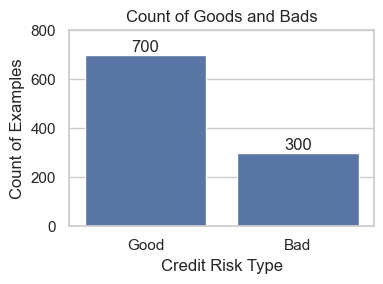

In [165]:
#========================================================================
# Step 2: Plot Response

# Summarise for the plot
df_smry=df['bad_flag'].value_counts().reset_index()
df_smry['bad_flag']=df_smry['bad_flag'].map({0:'Good', 1:'Bad'})

# Response plot
plt.figure(figsize=(4,3))
ax=sns.barplot(df_smry, x='bad_flag', y='count')
ax.bar_label(ax.containers[0])
ax.set_xlabel('Credit Risk Type')
ax.set_ylabel('Count of Examples')
plt.ylim(0, 800) 
plt.title('Count of Goods and Bads')
plt.tight_layout()
plt.savefig("credit-data-count-goods-bads.png", dpi=300)
plt.show()
#========================================================================

C:\Users\markt\AppData\Local\Temp\ipykernel_11924\2115833559.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


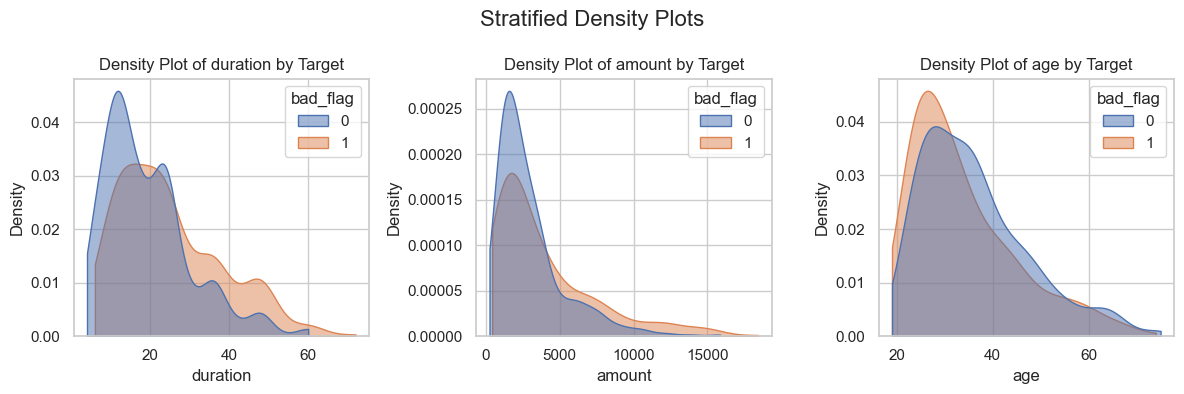

In [166]:
#========================================================================
# Step 3: Plot Numeric Features

# Numeric Features
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('bad_flag')
num_numeric_cols=len(numeric_cols)

# KDE Plots
fig, axes = plt.subplots(1, num_numeric_cols, figsize=(12, 4), constrained_layout=True)
for i, this_var in enumerate(numeric_cols):
    sns.kdeplot(data=df, 
                x=this_var, 
                hue='bad_flag', 
                fill=True, 
                common_norm=False,
                cut=0,
                alpha=0.5,
                ax=axes[i])
    axes[i].set_title(f'Density Plot of {this_var} by Target', fontsize=12)
fig.suptitle('Stratified Density Plots', fontsize=16)
plt.tight_layout()
plt.savefig("credit-data-numeric-features.png", dpi=300)
plt.show()
#========================================================================

# Insights from Stratified KDE Plots

The stratified KDE (Kernel Density Estimate) plots provide insights into the distribution of numerical features(`duration`, `amount`, `age`) stratified by the target variable (`bad_flag`). Here are the key observations:

## 1. Duration
- The distribution of `duration` for both good and bad credit risks shows that longer durations are more common among bad credit risks.
- There is a noticeable peak for bad credit risks at higher durations, indicating that longer loan durations might be associated with higher credit risk.

## 2. Amount
- The distribution of `amount` for both good and bad credit risks shows that higher loan amounts are more common among bad credit risks.
- There is a noticeable peak for bad credit risks at higher loan amounts, suggesting that larger loan amounts might be associated with higher credit risk.

## 3. Age
- The distribution of `age` for both good and bad credit risks shows that younger individuals are more common among bad credit risks.
- There is a noticeable peak for bad credit risks at lower ages, indicating that younger age might be associated with higher credit risk.

---

Overall, the stratified KDE plots suggest that longer loan durations, higher loan amounts, and younger ages are associated with higher credit risk. These insights can be useful for understanding the characteristics of high-risk loans and individuals.


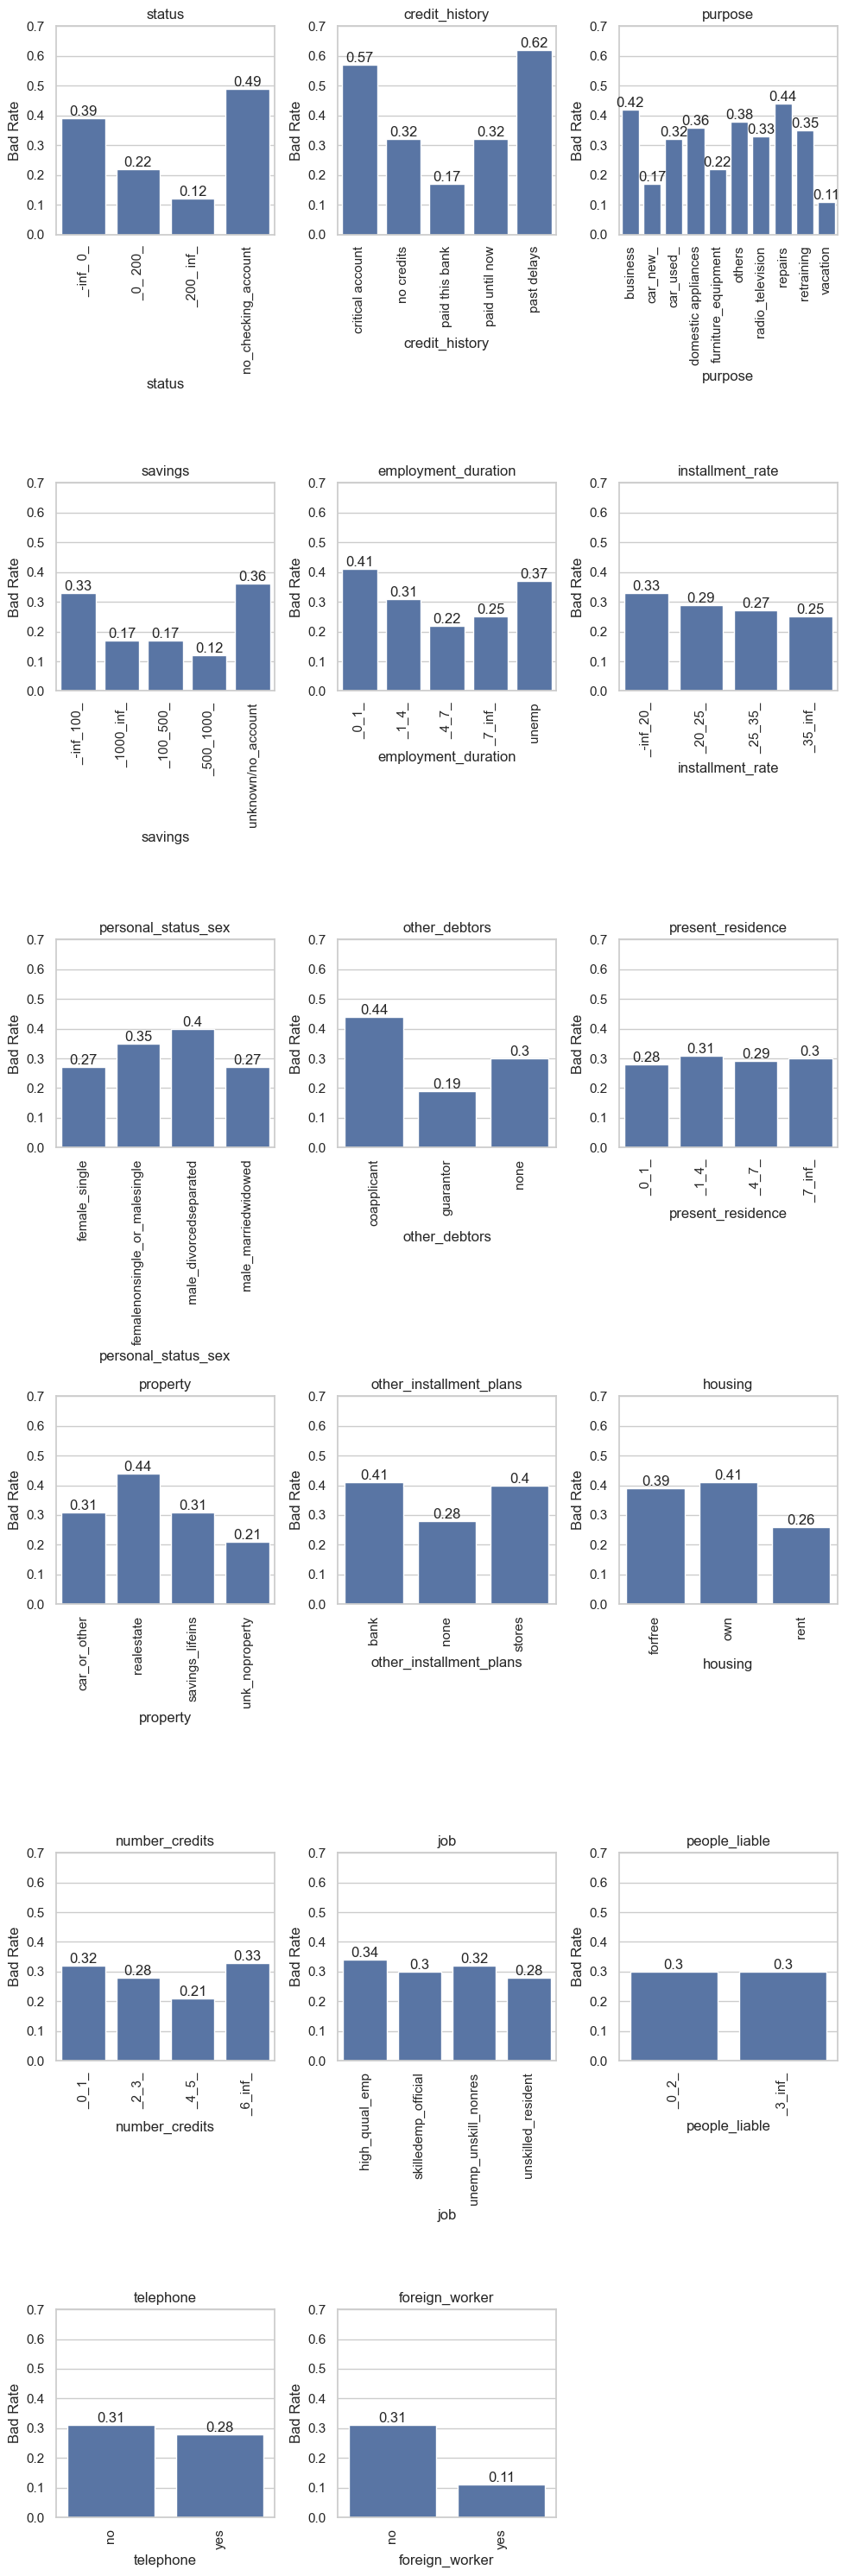

In [186]:
#========================================================================
# Step 4: Plot Categorical Features

# Identify categorical columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns
num_categorical_cols = len(categorical_cols)

# Set up grid dimensions
cols = 3
rows = (num_categorical_cols + cols - 1) // cols  # Calculate required rows

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))
axes = axes.flatten()  # Flatten to make indexing easier

# Loop over categorical columns
for i, col in enumerate(categorical_cols):
    df_smry = df[['bad_flag', col]].groupby(col).mean().reset_index().round(2)

    ax = axes[i]  # Get the current axis
    sns.barplot(data=df_smry, x=col, y='bad_flag', ax=ax)
    ax.bar_label(ax.containers[0])
    ax.set_xlabel(col)
    ax.set_ylabel('Bad Rate')
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylim(0, 0.7)
    #ax.set_title(f'Bad Rate by {col}')
    ax.set_title(f'{col}')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("credit-data-categorical-features.png", dpi=300)
plt.show()
#========================================================================

--------------------
### WoE Table for status ###
bad_flag               0    1  Total   P0   P1   woe  iv_comp
status                                                       
_-inf_ 0_            164  105    269 0.23 0.35  0.40     0.05
_0_ 200_              49   14     63 0.07 0.05 -0.41     0.01
_200_ inf_           348   46    394 0.50 0.15 -1.18     0.40
no_checking_account  139  135    274 0.20 0.45  0.82     0.21
IV for status: 0.6660
Gini for status: 0.4155
--------------------

--------------------
### WoE Table for duration ###
bad_flag            0    1  Total   P0   P1   woe  iv_comp
duration                                                  
(-99999.0, 12.0]  283   76    359 0.40 0.25 -0.47     0.07
(12.0, 24.0]      289  122    411 0.41 0.41 -0.02     0.00
(24.0, 36.0]       86   57    143 0.12 0.19  0.44     0.03
(36.0, 99999.0]    42   45     87 0.06 0.15  0.92     0.08
IV for duration: 0.1824
Gini for duration: 0.2240
--------------------

--------------------
### WoE Tab

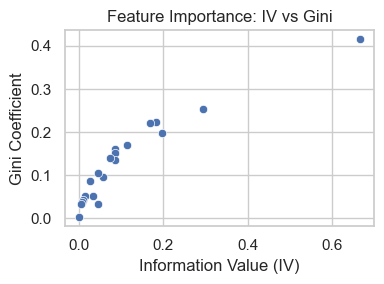

In [197]:
#========================================================================
# Step 5: Feature Importance

#--------------------
# Binned dataset
all_cols=df.drop('bad_flag', axis=1).columns.to_list()
df_binned= pd.DataFrame(index=df.index)
for col in all_cols:
    df_binned.loc[:,[col]]=bin_feature(df['bad_flag'], df[col], num_bins=4)
#--------------------

#--------------------
# WoE Encoding
encoder = ce.WOEEncoder(cols=all_cols, regularization=0)
encoder.fit(df_binned[all_cols], df['bad_flag'])
df_binned2 = encoder.transform(df_binned[all_cols])
df_binned2['bad_flag']=df['bad_flag']
#--------------------

#--------------------
# Numeric Dataset
num_cols=df.select_dtypes(include=[np.number]).columns.to_list()
cat_cols=df.select_dtypes(exclude=[np.number]).columns.to_list()
df_binned3=pd.concat([df[num_cols], df_binned2[cat_cols]], axis=1)
df_binned3=df_binned3[df.columns.to_list()]
#--------------------

#--------------------
# WoE, IV and Gini
all_ivs=[]
all_ginis=[]
all_cols=df.drop('bad_flag', axis=1).columns.to_list()
for col in all_cols:
    woe_table, iv=woe_iv_calc(df['bad_flag'], df[col], num_bins=4)
    gini_val=gini(df_binned2['bad_flag'], df_binned2[col], decimals=4)
    all_ivs.append(iv)
    all_ginis.append(gini_val)
    print('--------------------')
    print(f'### WoE Table for {col} ###')
    print(woe_table)
    print(f'IV for {col}: {iv:.4f}')
    print(f'Gini for {col}: {gini_val:.4f}')
    print('--------------------')
    print('')
#--------------------

#--------------------
# Feature Importance
importance=pd.DataFrame({'feature':all_cols, 'IV':all_ivs, 'Gini':all_ginis})\
    .sort_values('IV', ascending=False)\
    .reset_index(drop=True)
print('--------------------')
print('## Feature Importance ##')
print(importance)
print('--------------------')
print('')

plt.figure(figsize=(4, 3))
sns.scatterplot(data=importance, x='IV', y='Gini')
plt.title('Feature Importance: IV vs Gini')
plt.xlabel('Information Value (IV)')
plt.ylabel('Gini Coefficient')
plt.tight_layout()
plt.savefig("credit-data-feature-importance.png", dpi=300)
plt.show()
#--------------------
#========================================================================

In [ ]:
#========================================================================
# Step 6: Prepare for Modelling

# X and y
X=df_binned3.drop(['bad_flag'], axis=1)
y=df_binned3['bad_flag']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#========================================================================

In [201]:
#========================================================================
# Step 7: Modelling
#- XGBoost
#- LightGBM
#- CatBoost
#- Random Forest
#- Logistic Regression
#- Naive Bayes
#- K-Nearest Neighbours
#- Support Vector Machine
#- Neural Network (Multilayer Perceptron)
#- Linear Discriminant Analysis

In [202]:
#--------------------
# XGBoost
model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)
pred_xgb=pd.DataFrame({'model': 'xgb', 'target': y_test, 'pred': model_xgb.predict_proba(X_test)[:,1]})
#--------------------

In [203]:
#--------------------
# Light GBM
model_lgb=LGBMClassifier(verbose=-1)
model_lgb.fit(X_train, y_train)
pred_lgb=pd.DataFrame({'model': 'lgb', 'target': y_test, 'pred': model_lgb.predict_proba(X_test)[:,1]})
#--------------------

In [204]:
#--------------------
# Catboost
model_cat=CatBoostClassifier(verbose=False)
model_cat.fit(X_train, y_train)
pred_cat=pd.DataFrame({'model': 'cat', 'target': y_test, 'pred': model_cat.predict_proba(X_test)[:,1]})
#--------------------

In [205]:
#--------------------
# Random Forrest
model_rfc=RandomForestClassifier()
model_rfc.fit(X_train, y_train)
pred_rfc=pd.DataFrame({'model': 'rf', 'target': y_test, 'pred': model_rfc.predict_proba(X_test)[:,1]})
#--------------------

In [206]:
#--------------------
# Logistic Regression
model_lrg=LogisticRegression(penalty=None, solver='newton-cg')
model_lrg.fit(X_train, y_train)
pred_lrg=pd.DataFrame({'model': 'lr', 'target': y_test, 'pred': model_lrg.predict_proba(X_test)[:,1]})
#--------------------

In [207]:
#--------------------
# Naive Bayes
model_nb=GaussianNB()
model_nb.fit(X_train,  y_train)
pred_nb=pd.DataFrame({'model': 'nb', 'target': y_test, 'pred': model_nb.predict_proba(X_test)[:,1]})
#--------------------

In [208]:
#--------------------
# K-Nearest Neighbours
model_knn=KNeighborsClassifier()
model_knn.fit(X_train, y_train)
pred_knn=pd.DataFrame({'model': 'knn', 'target': y_test, 'pred': model_knn.predict_proba(X_test)[:,1]})
#--------------------

In [209]:
#--------------------
# Support Vector Machine
model_svc=SVC(probability=True)
model_svc.fit(X_train, y_train)
pred_svc=pd.DataFrame({'model': 'svc', 'target': y_test, 'pred': model_svc.predict_proba(X_test)[:,1]})
#--------------------

In [210]:
#--------------------
# Neural Network - Multilayer Perception
model_mlp=MLPClassifier(hidden_layer_sizes=(10,), max_iter=2000)
model_mlp.fit(X_train, y_train)
pred_mlp=pd.DataFrame({'model': 'nn', 'target': y_test, 'pred': model_mlp.predict_proba(X_test)[:,1]})
#--------------------

In [211]:
#--------------------
# Linear Discriminant Analysis
model_lda=LinearDiscriminantAnalysis()
model_lda.fit(X_train, y_train)
pred_lda=pd.DataFrame({'model': 'lda', 'target': y_test, 'pred': model_lda.predict_proba(X_test)[:,1]})
#--------------------
#========================================================================

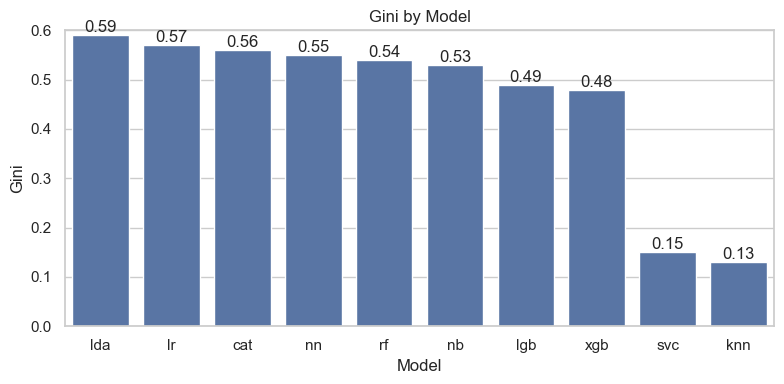

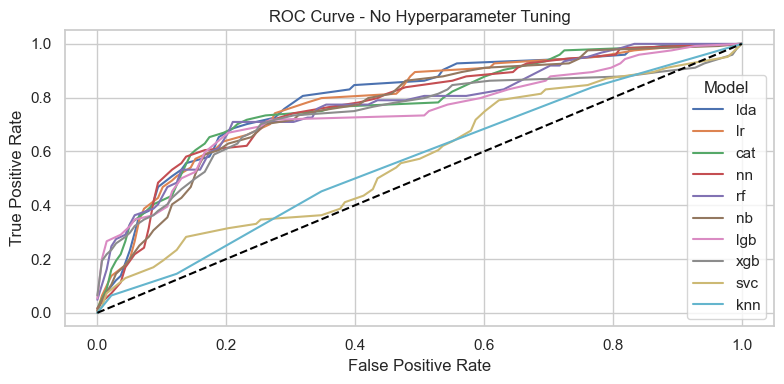

In [219]:
#========================================================================
# Step 8: Collate Results

#--------------------
# Join all predictions
pred=pd.concat([pred_xgb, 
                pred_lgb, 
                pred_cat, 
                pred_rfc, 
                pred_lrg, 
                pred_nb, 
                pred_knn, 
                pred_svc, 
                pred_mlp, 
                pred_lda], axis=0).reset_index(drop=True)
#--------------------

#--------------------
# Gini
gini_df=gini_group(y_true=pred['target'], 
                   y_score=pred['pred'], 
                   group=pred['model'], 
                   round=2)\
                  .sort_values('Gini', ascending=False)\
                  .reset_index()

# Gini Barplot
plt.figure(figsize=(8, 4))
ax=sns.barplot(data=gini_df, y='Gini', x='group')
ax.bar_label(ax.containers[0])
plt.ylabel('Gini')
plt.xlabel('Model')
plt.ylim(0, 0.6)
plt.title('Gini by Model')
plt.tight_layout()
plt.savefig("credit-data-gini.png", dpi=300)
plt.show()
#--------------------

#--------------------
# ROC Curve
roc_curve_df=roc_curve_group(y_true=pred['target'], 
                             y_score=pred['pred'], 
                             group=pred['model'], 
                             round=6)

roc_curve_df2=pd.merge(gini_df, 
                       roc_curve_df, 
                       left_on=['group'], 
                       right_on=['Model'], 
                       how='left')

# Plot ROC Curve
plt.figure(figsize=(8, 4))
sns.lineplot(data=roc_curve_df2, x='fpr', y='tpr', hue='Model', errorbar=None)
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - No Hyperparameter Tuning')
plt.tight_layout()
plt.savefig("credit-data-roc-curve.png", dpi=300)
plt.show()
#--------------------
#========================================================================

In [ ]:

roc_curve_df2

,index,group,Gini,Model,fpr,tpr
0,9,lda,0.59,lda,0.00,0.00
1,9,lda,0.59,lda,0.01,0.00
2,9,lda,0.59,lda,0.01,0.11
3,9,lda,0.59,lda,0.03,0.11
4,9,lda,0.59,lda,0.03,0.13
5,9,lda,0.59,lda,0.04,0.13
6,9,lda,0.59,lda,0.04,0.15
7,9,lda,0.59,lda,0.04,0.15
8,9,lda,0.59,lda,0.04,0.23
9,9,lda,0.59,lda,0.05,0.23
